# Eksplorasi Dataset `commonsense_170k.json`

Dataset gabungan untuk fine-tuning commonsense reasoning (gaya LLM-Adapters / DenseLoRA). Berisi instruksi multiple-choice / true-false dari beberapa benchmark publik:

| Sub-dataset | Format | Jawaban |
|---|---|---|
| BoolQ | true/false | `true` / `false` |
| PIQA | 2 solusi | `solution1` / `solution2` |
| SIQA | 3 jawaban | `answer1` / `answer2` / `answer3` |
| HellaSwag | 4 ending | `ending1`..`ending4` |
| WinoGrande | isi titik-titik, 2 opsi | `option1` / `option2` |
| ARC-e / ARC-c | 4–5 jawaban | `answer1`..`answerN` |
| OBQA | 4 jawaban | `answer1`..`answer4` |

Notebook ini menganalisis:
1. Statistik dasar (jumlah, schema, field kosong)
2. Klasifikasi otomatis tipe tugas
3. Distribusi panjang (karakter & token)
4. Distribusi label per tipe tugas (cek class imbalance)
5. Sampling contoh per tipe
6. Analisis kosakata & kata kunci instruksi
7. Implikasi untuk training (cutoff length, sampling weight)

## 1. Load data & cek schema

In [1]:
import json, re, random, statistics
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("../commonsense_170k.json")
assert DATA_PATH.exists(), f"File tidak ditemukan: {DATA_PATH.resolve()}"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total contoh: {len(data):,}")
print(f"Keys per item : {list(data[0].keys())}")
print(f"Ukuran file   : {DATA_PATH.stat().st_size / 1024**2:.1f} MB")

Total contoh: 170,420
Keys per item : ['instruction', 'input', 'output', 'answer']
Ukuran file   : 92.1 MB


In [2]:
# Periksa konsistensi schema
expected_keys = {"instruction", "input", "output", "answer"}
weird = [i for i, x in enumerate(data) if set(x.keys()) != expected_keys]
print(f"Item dengan schema tak standar: {len(weird)}")

empty_input  = sum(1 for x in data if not x["input"])
empty_instr  = sum(1 for x in data if not x["instruction"])
empty_output = sum(1 for x in data if not x["output"])
empty_answer = sum(1 for x in data if not x["answer"])

print(f"input kosong       : {empty_input:,}/{len(data):,}  ({empty_input/len(data):.1%})")
print(f"instruction kosong : {empty_instr:,}")
print(f"output kosong      : {empty_output:,}")
print(f"answer kosong      : {empty_answer:,}")

Item dengan schema tak standar: 0
input kosong       : 170,420/170,420  (100.0%)
instruction kosong : 0
output kosong      : 0
answer kosong      : 0


**Catatan:** semua `input` kosong, jadi semua sinyal pelatihan ada di `instruction` + `output`. Format `output` selalu `"the correct answer is <label>"`, sedangkan `answer` adalah label murni — keduanya redundan.

## 2. Klasifikasi tipe tugas

Tidak ada field `task` eksplisit, jadi kita deteksi dari pola teks instruksi.

In [3]:
def classify_task(item):
    ins = item["instruction"].lower()
    if "true or false" in ins:
        return "BoolQ"
    if "fill in the blank" in ins and "option1" in ins:
        return "WinoGrande"
    if "choose the correct ending" in ins:
        return "HellaSwag"
    if "choose the correct solution" in ins and "solution1" in ins:
        return "PIQA"
    if re.search(r"answer\d", ins):
        n = len(set(re.findall(r"answer\d", ins)))
        # Heuristik: SIQA = 3 opsi, OBQA/ARC-e = 4, ARC-c = 4-5, OBQA = 4
        if n == 3:
            return "SIQA"
        if n == 4:
            return "MCQ-4 (OBQA / ARC-e)"
        if n == 5:
            return "MCQ-5 (ARC-c)"
        return f"MCQ-{n}"
    return "OTHER"

df = pd.DataFrame(data)
df["task"] = df.apply(classify_task, axis=1)
df["instr_len_char"]  = df["instruction"].str.len()
df["output_len_char"] = df["output"].str.len()
df["instr_len_word"]  = df["instruction"].str.split().str.len()

task_counts = df["task"].value_counts()
print(task_counts)
print(f"\nTotal: {task_counts.sum():,}  |  jenis tugas: {len(task_counts)}")

task
WinoGrande              63238
HellaSwag               39903
SIQA                    33417
PIQA                    16113
BoolQ                    9429
MCQ-4 (OBQA / ARC-e)     8315
MCQ-5 (ARC-c)               5
Name: count, dtype: int64

Total: 170,420  |  jenis tugas: 7


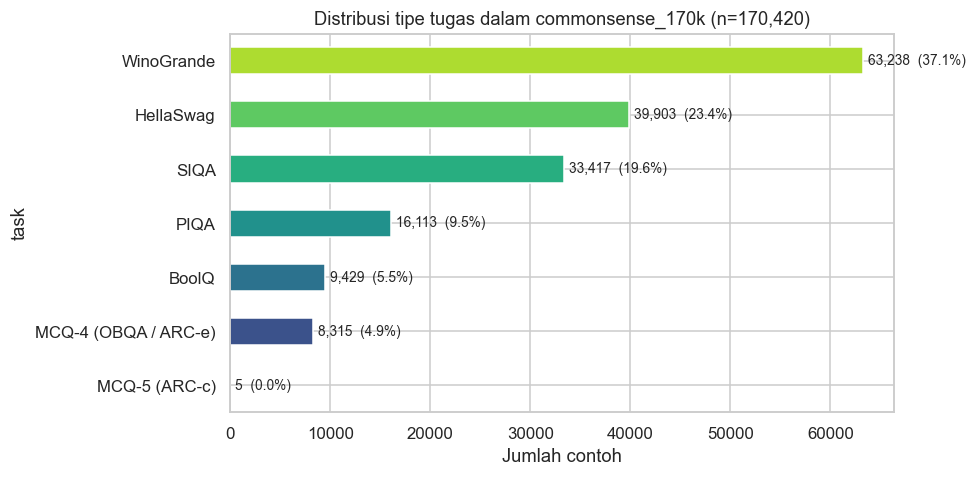

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
task_counts.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(task_counts)))
ax.set_xlabel("Jumlah contoh")
ax.set_title(f"Distribusi tipe tugas dalam commonsense_170k (n={len(df):,})")
for i, v in enumerate(task_counts.sort_values().values):
    ax.text(v + 500, i, f"{v:,}  ({v/len(df):.1%})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Distribusi panjang instruksi (karakter & kata)

In [5]:
print("Statistik panjang instruksi (karakter):")
print(df["instr_len_char"].describe(percentiles=[.5, .9, .95, .99]).round(1))
print("\nStatistik panjang instruksi (kata):")
print(df["instr_len_word"].describe(percentiles=[.5, .9, .95, .99]).round(1))
print("\nStatistik panjang output (karakter):")
print(df["output_len_char"].describe().round(1))

Statistik panjang instruksi (karakter):
count    170420.0
mean        422.7
std         336.5
min         115.0
50%         267.0
90%        1104.0
95%        1229.0
99%        1391.0
max        4504.0
Name: instr_len_char, dtype: float64

Statistik panjang instruksi (kata):
count    170420.0
mean         69.4
std          57.1
min          17.0
50%          43.0
90%         185.0
95%         206.0
99%         231.0
max         770.0
Name: instr_len_word, dtype: float64

Statistik panjang output (karakter):
count    170420.0
mean         29.0
std           0.9
min          26.0
25%          29.0
50%          29.0
75%          29.0
max          31.0
Name: output_len_char, dtype: float64


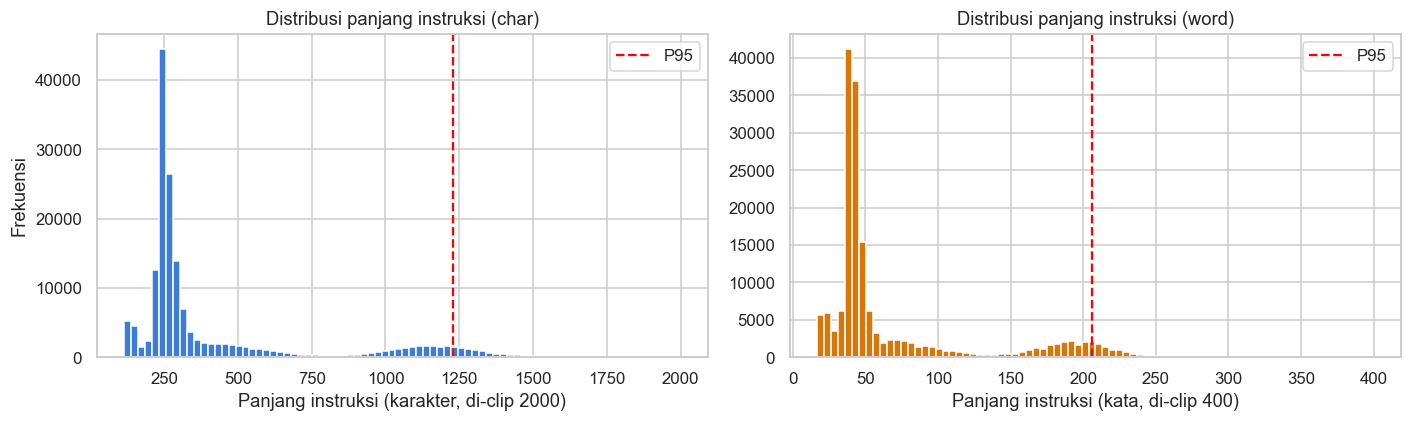

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["instr_len_char"].clip(upper=2000), bins=80, color="#3b7dd8", edgecolor="white")
axes[0].axvline(df["instr_len_char"].quantile(0.95), color="red", ls="--", label="P95")
axes[0].set_xlabel("Panjang instruksi (karakter, di-clip 2000)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi panjang instruksi (char)")
axes[0].legend()

axes[1].hist(df["instr_len_word"].clip(upper=400), bins=80, color="#d97706", edgecolor="white")
axes[1].axvline(df["instr_len_word"].quantile(0.95), color="red", ls="--", label="P95")
axes[1].set_xlabel("Panjang instruksi (kata, di-clip 400)")
axes[1].set_title("Distribusi panjang instruksi (word)")
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\jerem\AppData\Local\Temp\ipykernel_21040\4199389229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="task", y="instr_len_word", order=order, ax=ax,


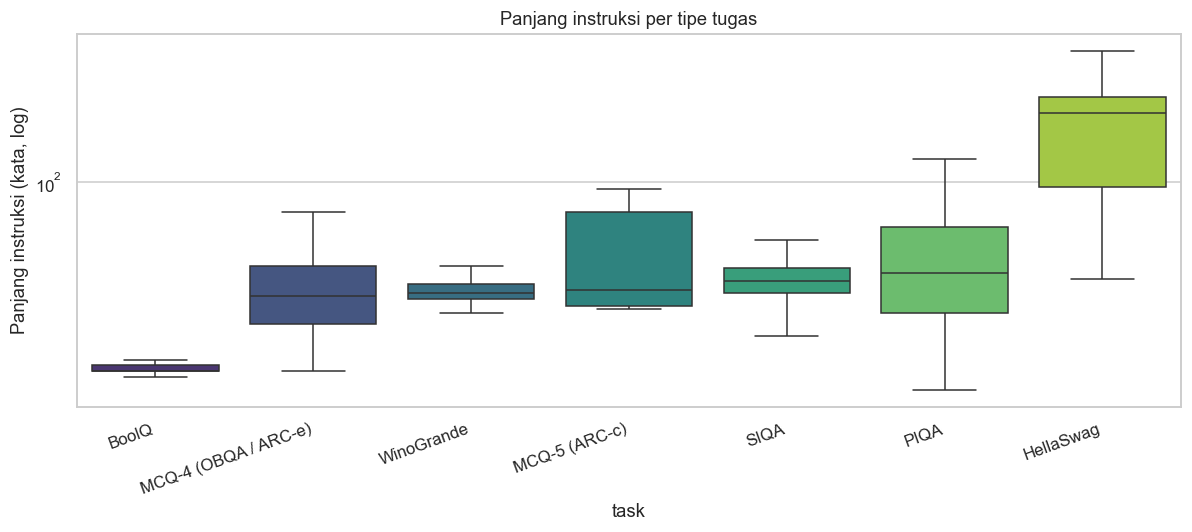


Median / P95 panjang kata per tugas:
                      count  median    p95
task                                      
BoolQ                  9429    21.0   24.0
HellaSwag             39903   176.0  228.0
MCQ-4 (OBQA / ARC-e)   8315    39.0   74.0
MCQ-5 (ARC-c)             5    41.0   90.8
PIQA                  16113    47.0  126.0
SIQA                  33417    44.0   57.0
WinoGrande            63238    40.0   47.0


In [7]:
# Boxplot panjang per tipe tugas — useful untuk tentukan cutoff_len yang adil
fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby("task")["instr_len_word"].median().sort_values().index
sns.boxplot(data=df, x="task", y="instr_len_word", order=order, ax=ax,
            showfliers=False, palette="viridis")
ax.set_yscale("log")
ax.set_ylabel("Panjang instruksi (kata, log)")
ax.set_title("Panjang instruksi per tipe tugas")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nMedian / P95 panjang kata per tugas:")
print(df.groupby("task")["instr_len_word"].agg(["count", "median",
                                                  lambda s: s.quantile(0.95)]).rename(columns={"<lambda_0>": "p95"}))

## 4. Distribusi label per tipe tugas (class balance)

Penting untuk fine-tuning: kalau label tidak seimbang, model bisa belajar shortcut (selalu pilih opsi mayoritas).

In [8]:
label_dist = (df.groupby(["task", "answer"]).size()
                .groupby(level=0).apply(lambda s: (s / s.sum() * 100).round(2))
                .unstack(fill_value=0))
label_dist

,answer,answer1,answer2,answer3,answer4,answer5,ending1,ending2,ending3,ending4,false,option1,option2,solution1,solution2,true
task,task,,,,,,,,,,,,,,,
BoolQ,BoolQ,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.01,0.01,37.68,0.00,0.00,0.00,0.00,62.3
HellaSwag,HellaSwag,0.00,0.00,0.00,0.00,0.0,25.03,25.14,24.72,25.11,0.00,0.00,0.00,0.00,0.00,0.0
MCQ-4 (OBQA / ARC-e),MCQ-4 (OBQA / ARC-e),25.97,25.20,24.21,24.63,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
MCQ-5 (ARC-c),MCQ-5 (ARC-c),20.00,0.00,20.00,20.00,40.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
PIQA,PIQA,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.98,50.02,0.0
SIQA,SIQA,33.75,33.45,32.80,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
WinoGrande,WinoGrande,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,50.05,49.95,0.00,0.00,0.0


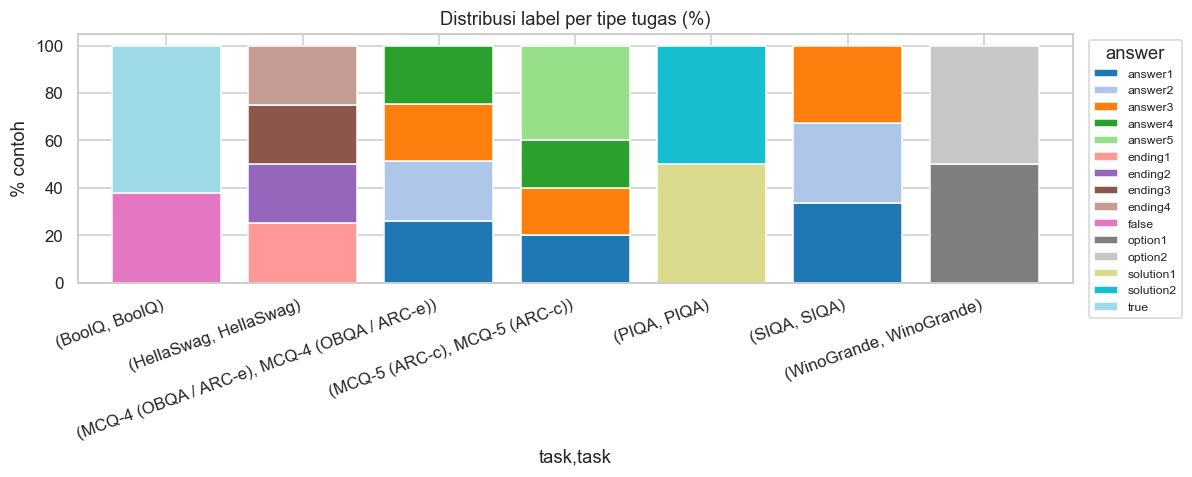


Rasio imbalance (max/min) per tugas:
task
BoolQ                   5874.00
MCQ-5 (ARC-c)              2.00
MCQ-4 (OBQA / ARC-e)       1.07
SIQA                       1.03
HellaSwag                  1.02
PIQA                       1.00
WinoGrande                 1.00
dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
label_dist.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.8)
ax.set_ylabel("% contoh")
ax.set_title("Distribusi label per tipe tugas (%)")
ax.legend(title="answer", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Cek imbalance: rasio label terbesar:terkecil per tugas
imb = (df.groupby(["task", "answer"]).size().groupby(level=0)
         .agg(lambda s: round(s.max() / max(s.min(), 1), 2)))
print("\nRasio imbalance (max/min) per tugas:")
print(imb.sort_values(ascending=False))

## 5. Sampling contoh per tipe tugas

In [10]:
random.seed(42)
for task in df["task"].value_counts().index:
    sub = df[df["task"] == task]
    ex = sub.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
    print("=" * 80)
    print(f"TASK: {task}   (n={len(sub):,})")
    print("-" * 80)
    print("INSTRUCTION:")
    print(ex["instruction"][:600] + ("..." if len(ex["instruction"]) > 600 else ""))
    print("\nOUTPUT :", ex["output"])
    print("ANSWER :", ex["answer"])
    print()

TASK: WinoGrande   (n=63,238)
--------------------------------------------------------------------------------
INSTRUCTION:
Please choose the correct answer to fill in the blank to complete the given sentence: Felicia replied to an email from Christine, as _ asked some information about the employee benefit from the company they work for 10 years.

Option1: Felicia Option2: Christine Answer format: option1/option2

OUTPUT : the correct answer is option2
ANSWER : option2

TASK: HellaSwag   (n=39,903)
--------------------------------------------------------------------------------
INSTRUCTION:
Please choose the correct ending to complete the given sentence: Relationships: [header] How to help a friend cope with a breakup (for girls ) [title] Actively listen to your friend. [step] Active listening is an approach you can use to get the most out of your interaction with your friend. When you're actively engaged and communicating openly with your friend, you are showing your friend that you 

## 6. Kata kunci instruksi (n-gram pembuka)

Karena setiap sub-dataset punya prompt template tetap, kita bisa lihat 5-gram pembuka instruksi untuk memverifikasi pola template.

In [11]:
def first_ngram(text, n=8):
    return " ".join(text.split()[:n])

openings = Counter(first_ngram(x) for x in df["instruction"])
print("Top 10 pembuka instruksi (8 kata pertama):\n")
for phrase, c in openings.most_common(10):
    print(f"  {c:>7,}  {phrase!r}")

Top 10 pembuka instruksi (8 kata pertama):

   63,238  'Please choose the correct answer to fill in'
   41,737  'Please choose the correct answer to the question:'
   39,905  'Please choose the correct ending to complete the'
   16,113  'Please choose the correct solution to the question:'
    9,427  'Please answer the following question with true or'


C:\Users\jerem\AppData\Local\Temp\ipykernel_21040\834044817.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wf, y="kata", x="frekuensi", palette="mako", ax=ax)


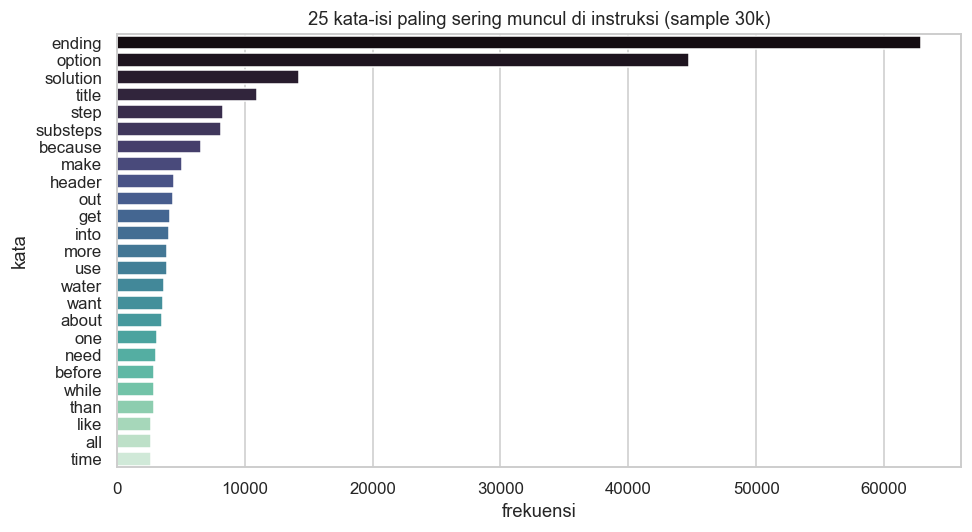

In [12]:
# Top kata dalam instruksi (di luar stopword sederhana)
stop = set("""the a an of to in on for is are was were be been being and or but if then else with as by at
from this that these those it its he she they them his her their what which who whom whose how why where when do does did
i you we my your our me us so not no yes can could would should will shall may might have has had having please answer
format question following choose correct option1 option2 ending1 ending2 ending3 ending4 solution1 solution2
answer1 answer2 answer3 answer4 answer5 answer6 true false fill blank complete given sentence""".split())

tok = re.compile(r"[A-Za-z][A-Za-z\-']+")
word_freq = Counter()
# sample 30k untuk hemat memori
for ins in df["instruction"].sample(30_000, random_state=0):
    for w in tok.findall(ins.lower()):
        if w not in stop and len(w) > 2:
            word_freq[w] += 1

top_words = word_freq.most_common(25)
wf = pd.DataFrame(top_words, columns=["kata", "frekuensi"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=wf, y="kata", x="frekuensi", palette="mako", ax=ax)
ax.set_title("25 kata-isi paling sering muncul di instruksi (sample 30k)")
plt.tight_layout()
plt.show()

## 7. Estimasi panjang token (untuk `cutoff_len` training)

Aproksimasi token tanpa load tokenizer LLaMA: rata-rata 1 token ≈ 4 karakter untuk teks Inggris (cukup akurat untuk SentencePiece BPE LLaMA). Kalau punya `transformers` + tokenizer LLaMA, ganti dengan tokenisasi nyata di sel berikutnya.

  cutoff_len=128    -> 79.43% contoh ter-cover penuh (approx)
  cutoff_len=256    -> 87.42% contoh ter-cover penuh (approx)
  cutoff_len=512    -> 99.99% contoh ter-cover penuh (approx)
  cutoff_len=768    -> 100.00% contoh ter-cover penuh (approx)
  cutoff_len=1024   -> 100.00% contoh ter-cover penuh (approx)


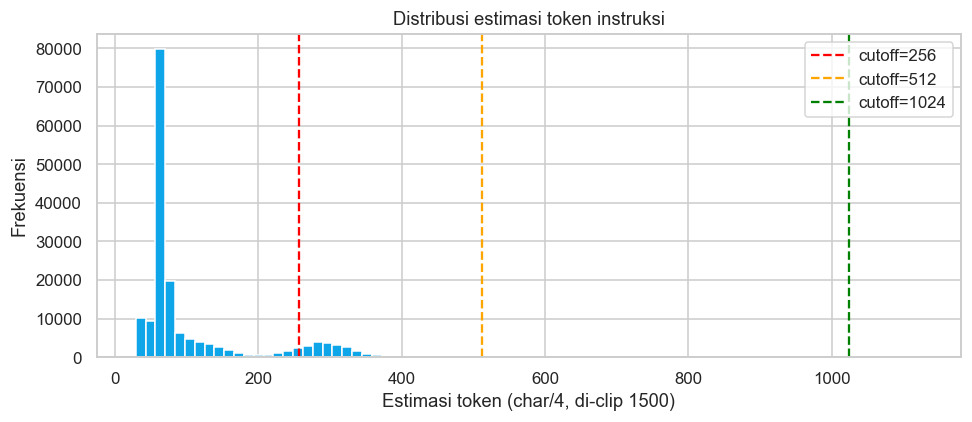

In [13]:
df["approx_tokens"] = (df["instr_len_char"] / 4).round().astype(int)

for cutoff in [128, 256, 512, 768, 1024]:
    pct = (df["approx_tokens"] <= cutoff).mean() * 100
    print(f"  cutoff_len={cutoff:<5}  -> {pct:5.2f}% contoh ter-cover penuh (approx)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["approx_tokens"].clip(upper=1500), bins=80, color="#0ea5e9", edgecolor="white")
for c, col in zip([256, 512, 1024], ["red", "orange", "green"]):
    ax.axvline(c, color=col, ls="--", label=f"cutoff={c}")
ax.set_xlabel("Estimasi token (char/4, di-clip 1500)")
ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi estimasi token instruksi")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# OPSIONAL: tokenisasi nyata pakai LLaMA tokenizer (butuh transformers + sentencepiece + akses ke checkpoint)
# Comment-in kalau lingkungan sudah siap.
#
# from transformers import AutoTokenizer
# tok = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")  # atau LLaMA-3, sesuai eksperimen DenseLoRA
# sample = df.sample(5000, random_state=0)
# real_lens = [len(tok(x).input_ids) for x in sample["instruction"]]
# print("Real token stats (n=5k):")
# print(pd.Series(real_lens).describe(percentiles=[.5, .9, .95, .99]).round(1))

## 8. Duplikasi & kebocoran

Cek apakah ada instruksi duplikat (potensi data leakage saat split, atau sampel yang dihitung dua kali).

In [15]:
dup_full = df.duplicated(subset=["instruction"]).sum()
dup_pair = df.duplicated(subset=["instruction", "answer"]).sum()
print(f"Instruksi duplikat              : {dup_full:,}  ({dup_full/len(df):.2%})")
print(f"(instruksi, jawaban) duplikat   : {dup_pair:,}  ({dup_pair/len(df):.2%})")

# Lihat contoh duplikat
if dup_full:
    dup_examples = (df[df.duplicated(subset=["instruction"], keep=False)]
                      .sort_values("instruction").head(6))
    print("\nContoh instruksi yang muncul lebih dari sekali:\n")
    for _, row in dup_examples.iterrows():
        print(f"[{row['task']}] answer={row['answer']!r}  ::  {row['instruction'][:140]}...")
        print()

Instruksi duplikat              : 22,793  (13.37%)
(instruksi, jawaban) duplikat   : 22,786  (13.37%)

Contoh instruksi yang muncul lebih dari sekali:

[WinoGrande] answer='option2'  ::  Please choose the correct answer to fill in the blank to complete the given sentence:  _ hates chocolates so Patricia received chocolates as...

[WinoGrande] answer='option2'  ::  Please choose the correct answer to fill in the blank to complete the given sentence:  _ hates chocolates so Patricia received chocolates as...

[WinoGrande] answer='option2'  ::  Please choose the correct answer to fill in the blank to complete the given sentence: "The ability to finish what you start is what you need...

[WinoGrande] answer='option2'  ::  Please choose the correct answer to fill in the blank to complete the given sentence: "The ability to finish what you start is what you need...

[WinoGrande] answer='option2'  ::  Please choose the correct answer to fill in the blank to complete the given sentence: "The ab

## 9. Ringkasan & implikasi training

Berdasarkan analisis di atas, berikut catatan praktis untuk fine-tuning DenseLoRA pada dataset ini:

In [16]:
summary = pd.DataFrame({
    "n":               df.groupby("task").size(),
    "% total":         (df.groupby("task").size() / len(df) * 100).round(2),
    "median_words":    df.groupby("task")["instr_len_word"].median().astype(int),
    "p95_words":       df.groupby("task")["instr_len_word"].quantile(0.95).astype(int),
    "p95_approx_tok":  df.groupby("task")["approx_tokens"].quantile(0.95).astype(int),
    "n_label":         df.groupby("task")["answer"].nunique(),
    "label_imbalance": df.groupby(["task", "answer"]).size().groupby(level=0)
                          .agg(lambda s: round(s.max() / max(s.min(), 1), 2)),
}).sort_values("n", ascending=False)
summary

,n,% total,median_words,p95_words,p95_approx_tok,n_label,label_imbalance
task,,,,,,,
WinoGrande,63238,37.11,40,47,70,2,1.00
HellaSwag,39903,23.41,176,228,343,4,1.02
SIQA,33417,19.61,44,57,88,3,1.03
PIQA,16113,9.45,47,126,181,2,1.00
BoolQ,9429,5.53,21,24,39,4,5874.00
MCQ-4 (OBQA / ARC-e),8315,4.88,39,74,120,4,1.07
MCQ-5 (ARC-c),5,0.00,41,90,144,4,2.00


**Temuan utama:**

- Total **170.420** contoh, semua field `input` kosong — prompt builder cukup pakai cabang `else` (instruction-only) di `generate_prompt`.
- `output` selalu berformat `"the correct answer is <label>"` dan redundan dengan `answer`. Untuk loss masking, sasaran prediksi yang relevan adalah token-token label saja.
- Komposisi tugas **tidak seimbang**: WinoGrande (~37%) dan HellaSwag (~23%) mendominasi, sedangkan BoolQ hanya ~5,5%. Pertimbangkan **stratified evaluation** atau sample weighting kalau ingin akurasi merata.
- Label per tugas relatif seimbang (rasio max/min ≤ ~2 untuk mayoritas), jadi tidak perlu rebalancing label internal.
- HellaSwag jauh lebih panjang dari sub-dataset lain (P95 instruksi ratusan kata). Kalau pakai `cutoff_len=256` (default `lengths.ipynb` di repo), sebagian HellaSwag akan terpotong — periksa kolom `p95_approx_tok` di tabel di atas dan sesuaikan cutoff (umumnya **512** lebih aman, **1024** mengamankan ~99% data).
- Dataset bisa berisi duplikat instruksi (cek sel 8). Kalau jumlahnya signifikan, lakukan dedup sebelum split train/val.

**Rekomendasi konkret untuk `finetune.py`:**

1. `cutoff_len = 512` (atau 1024 untuk recall penuh).
2. Tetap pakai prompt-format Alpaca instruction-only — tidak perlu menangani `input` non-empty.
3. Pertimbangkan eval terpisah per sub-dataset benchmark (BoolQ, PIQA, SIQA, HellaSwag, WinoGrande, ARC-e, ARC-c, OBQA) — lihat `commonsense_evaluate.py` di repo.
4. Jika ingin men-debug under-performing task tertentu, filter `df[df.task == 'X']` dan lihat distribusi panjang/label-nya.